In [20]:
# Cell 1 — imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import io
from google.colab import files

In [21]:
# Cell 2 — load CSV
print("Please upload your CSV file.")
uploaded = files.upload()
if uploaded:
    filename = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    display(df.head())

Please upload your CSV file.


KeyboardInterrupt: 

In [12]:
# Cell 4 — build X_combined (radians + scaled pm25)
sensor_df['lat_rad'] = np.radians(sensor_df['latitude'])
sensor_df['lon_rad'] = np.radians(sensor_df['longitude'])
X = sensor_df[['lat_rad', 'lon_rad']].values
X_pm25 = sensor_df['pm25_scaled'].values * 0.3
X_combined = np.column_stack([X, X_pm25])

In [6]:
eps_km = 1.0
eps_rad = eps_km / 6371.0


In [11]:
# Cell 3 — filter to sensor_df (Poor+ AQI only)
sensor_df = df[(df['source_type'] == 'sensor') &
               (df['aqi_category'].isin(['Poor', 'Very Poor', 'Severe']))].copy()
scaler = StandardScaler()
sensor_df['pm25_scaled'] = scaler.fit_transform(sensor_df[['pm25']])
display(sensor_df.head())

,record_id,natural_key,timestamp,month,hour,day_of_week,season,station_uid,station_name,latitude,...,visibility_km,pollution_trapped,is_monsoon,alert_sent,resolved,predicted_spike_24h,photo_url,notes,source_type,pm25_scaled
0,1,anand_vihar__20260101_0000,2026-01-01 00:00:00,1,0,3,Winter,2553,Anand Vihar,28.6508,...,7.16,False,False,False,False,False,NaN,Auto-generated from sensor @2553,sensor,1.477345
1,2,lodhi_road__20260101_0000,2026-01-01 00:00:00,1,0,3,Winter,10122,Lodhi Road,28.5897,...,7.16,False,False,False,False,False,NaN,Auto-generated from sensor @10122,sensor,3.594571
5,6,iti_jahangirpuri__20260101_0000,2026-01-01 00:00:00,1,0,3,Winter,10113,ITI Jahangirpuri,28.7330,...,7.16,False,False,False,False,False,NaN,Auto-generated from sensor @10113,sensor,0.720338
7,8,wazirpur_dite__20260101_0000,2026-01-01 00:00:00,1,0,3,Winter,10114,Wazirpur DITE,28.7005,...,7.16,False,False,False,False,False,NaN,Auto-generated from sensor @10114,sensor,-0.058883
13,14,sonia_vihar_djb__20260101_0000,2026-01-01 00:00:00,1,0,3,Winter,10121,Sonia Vihar DJB,28.7101,...,7.16,False,False,False,False,False,NaN,Auto-generated from sensor @10121,sensor,0.228198


In [14]:
# Cell 6 — aggregate to station_summary
station_summary = sensor_df.groupby('station_name').agg(
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
    pm25_mean=('pm25', 'mean'),
    cluster=('cluster', lambda x: x.mode()[0])
).reset_index()
display(station_summary.head())

,station_name,latitude,longitude,pm25_mean,pm25_max,record_count,cluster
0,Anand Vihar,28.6508,77.3152,288.559461,916.6,2711,0
1,Burari Crossing,28.7256,77.2034,233.498413,475.5,504,0
2,ITI Jahangirpuri,28.7330,77.1720,270.921742,683.7,1711,0
3,ITI Shahdra Jhilmil,28.6721,77.3138,235.788991,447.5,109,0
4,ITO,28.6286,77.2410,265.768646,672.8,1617,0


In [13]:
# Cell 5 — fit DBSCAN, get labels
db = DBSCAN(eps=0.075, min_samples=3, metric='euclidean').fit(X_combined)
sensor_df['cluster'] = db.labels_
print(f"Clusters found: {len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)}")

Clusters found: 3
Noise points: 9


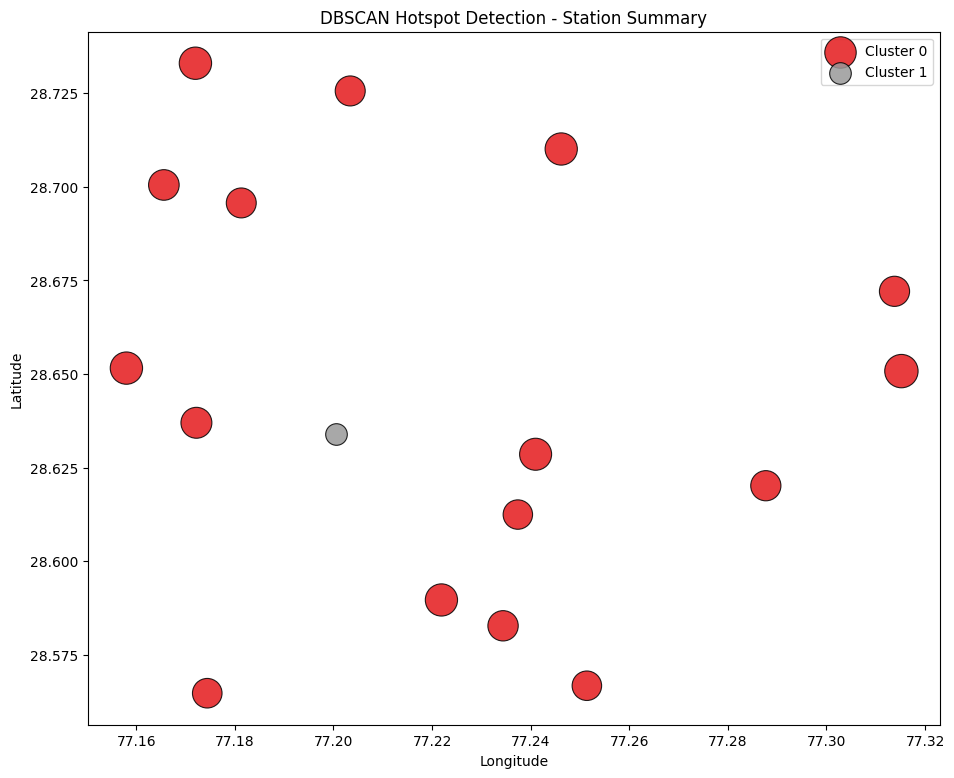

In [15]:
# Cell 7 — plot station_summary
plt.figure(figsize=(10, 6))
plt.scatter(station_summary['longitude'], station_summary['latitude'], c=station_summary['cluster'], cmap='Set1', edgecolors='k')
plt.title('DBSCAN Station Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [1]:
!pip install lightgbm -q

In [19]:
# Lag Feature Engineering
# Now correctly using sensor_df after reordering
df_sorted = sensor_df.sort_values(['station_name', 'timestamp']).copy()
for lag in [1, 3, 6, 12, 24]:
    df_sorted[f'pm25_lag_{lag}h'] = df_sorted.groupby('station_name')['pm25'].shift(lag)
print("Lag features generated successfully.")

Lag features generated successfully.


In [22]:
features = [
    'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h',
    'pm25_roll_mean_6h', 'pm25_roll_mean_24h',
    'hour', 'day_of_week', 'month',
    'temperature_c', 'humidity_pct', 'wind_speed_kmh',
    'pollution_trapped'
]

df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])

train = df_model[df_model['timestamp'].dt.month <= 4]
val   = df_model[df_model['timestamp'].dt.month == 5]
test  = df_model[df_model['timestamp'].dt.month == 6]

X_train, y_train = train[features], train['pm25_target']
X_val,   y_val   = val[features],   val['pm25_target']
X_test,  y_test  = test[features],  test['pm25_target']

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Train: 12881 | Val: 559 | Test: 201


In [23]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2339
[LightGBM] [Info] Number of data points in the train set: 12881, number of used features: 14
[LightGBM] [Info] Start training from score 267.674101
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
              n_estimators=500, random_state=42, subsample=0.8)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  {mae:.2f} µg/m³")
print(f"RMSE: {rmse:.2f} µg/m³")
print(f"MAPE: {mape:.2f}%")

MAE:  26.26 µg/m³
RMSE: 38.25 µg/m³
MAPE: 10.66%


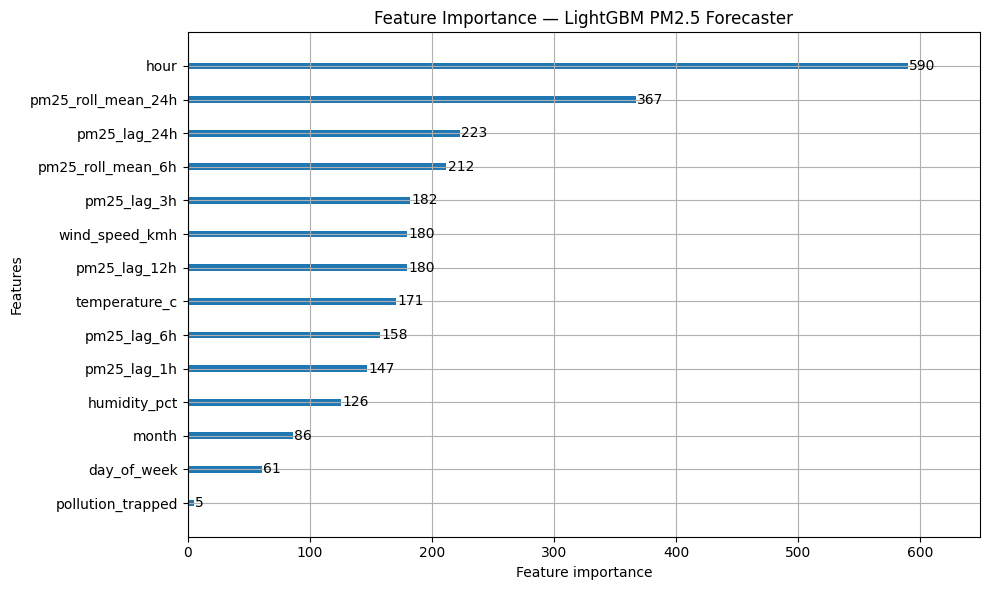

In [26]:
lgb.plot_importance(model, max_num_features=15, figsize=(10, 6))
plt.title('Feature Importance — LightGBM PM2.5 Forecaster')
plt.tight_layout()
plt.show()